[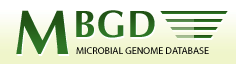](https://mbgd.nibb.ac.jp)
## eccb tutrial
## Program Install & Setup
1.   Install domclust (https://github.com/mbgd-prj/domclust)
2.   Prepare mbgd-pipeline scripts (https://github.com/mbgd-prj/mbgd-pipeline)

Other requirements not covered in this installation guide:
- python3
    - pandas
- perl > v.5.14
    - LWP:Simple (https://metacpan.org/pod/LWP::Simple)
    - JSON (https://metacpan.org/pod/JSON)
- diamond (https://github.com/bbuchfink/diamond)
- JRE (Java Runtime Environment)
- X11 server

In [ ]:
%cd ~

In [ ]:
!mkdir -p ~/mbgd_tutorial
%cd ~/mbgd_tutorial

In [ ]:
!pwd

## Install DomClust

In [ ]:
!git clone https://github.com/mbgd-prj/domclust.git

In [ ]:
%cd domclust

In [ ]:
!sh ./configure --prefix=${PWD}

In [ ]:
!make

In [ ]:
import sys
import os
target_path = os.path.join(os.getcwd(), "bin")
os.environ["PATH"] = target_path + ":" + os.environ["PATH"]

In [ ]:
print(os.environ.get("PATH"))

## Install MBGD-pipeline

In [ ]:
%cd ~/mbgd_tutorial

In [ ]:
!rm -rf mbgd-pipeline
!git clone https://github.com/mbgd-prj/mbgd-pipeline

In [ ]:
target_path = os.path.join(os.getcwd(), "mbgd-pipeline/bin")
os.environ["PATH"] = target_path + ":" + os.environ["PATH"]
print(os.environ.get("PATH"))

## Install CGB (Comparative Genome Browser) package
CGB is a tool to visualize multiple prokaryotic genomes based on synteny analysis. This package also contains the CoreAligner program to find syntenically conserved regions based on orthology analysis.

In [ ]:
!rm -f CGB.tgz
!wget https://mbgd.nibb.ac.jp/CGB/dist/CGB.tgz

In [ ]:
!tar xvf CGB.tgz

In [ ]:
!cp CGB/lib/CompareMap.jar ~/mbgd_tutorial/mbgd-pipeline/lib/
!cp CGB/bin/corealign ~/mbgd_tutorial/mbgd-pipeline/bin/

# Step-by-step orhtology analysis using MBGD
Create **bacillus** directory and work from there.

In [ ]:
!mkdir -p bacillus
%cd bacillus

## Download data from MBGD and format it as required
We will now perform clustering using data from four species of the genus Bacillus.


*   *Bacillus anthraci* : ban
*   *Bacillus cereus* : bce
*   *Bacillus subtilis* : bsu


In MBGD, each species is assigned a short (typically 3 to 5 letters) code, which is used when downloading data from the MBGD API. <br>
You can look up the species codes under "**Search for spid, taxid, etc.**" menu on the MBGD API toppage (https://mbgdapi.nibb.ac.jp).

In [ ]:
%%bash
export PERL_LWP_SSL_CA_FILE=/etc/ssl/cert.pem
mbgd2genetab.pl -outname=bacillus ban bce bsu

In [ ]:
!ls -l bacillus.faa bacillus.genetab

To run DomClust, you need a genetab file and a protein sequence file. Let's look at the genetab file you have just downloaded.

In [ ]:
!head bacillus.genetab

Genetab file (.genetab) is a tab-delimited file that contains the following information for each gene:

       species_code  gene_id  proteinseq_length  [center_position] [direction]
Only the first 3 columns are mandatory for DomClust. The latter 2 are used by CoreAligner for synteny analysis. This genetab file also contains genome and chromosome information, which are also used by CoreAligner.

Protein sequence file should be in FASTA format.

In [ ]:
!head bacillus.faa

In the sequence file, each sequence name should be in the following format:

    >species_code:gene_id
i.e., the species code and sequence name should be joined with a colon.<br> 
Note also that these names should be consistent with those in the genetab file.

## Add more genomes

In addition to published genomes in MBGD, users can analyze additioinal genomic data prepared by themselves. Here, we will use a metagenome assembled genome (MAG) of putative Bacillus species (GCA_001884825.1) annotated using Prokka. This data is included in the MBGD pipeline package. 

In [ ]:
!pwd
!cp -r ../mbgd-pipeline/test_mag/UG00001 .
!ls UG00001

The following scripts can be used to make a genetab file and a protein seuqne file.
 * **gff2genetab.pl**  converts a GFF file to a genetab file. Use -tag=_tagName_ option to specify from which tag in the last field of GFF the gene ID is taken.
 * **prepare_fastafile.pl** converts gene ID in the FASTA file into DomClust compatible form, i.e., sp_code:gene_id. Use -SPNAME=_spCode_ option to specify the species code.

In [ ]:
!gff2genetab.pl -tag=locus_tag UG00001/GCA_001884825.1.gff >UG00001.genetab
!prepare_fastafile.pl -SPNAME=UG00001 UG00001/GCA_001884825.1.faa > UG00001.faa

Please check species code and gene ID are correctly defined, i.e., consistent between the genetab file and the protein sequence file.
If it is OK, add these files into the original genetab and protein sequence files.

In [ ]:
!head UG00001.genetab UG00001.faa

In [ ]:
!cat UG00001.genetab >> bacillus.genetab
!cat UG00001.faa >> bacillus.faa

## Execute diamond
Perform an all-against-all search across the query genomes using Diamond.

In [ ]:
!diamond makedb --in bacillus.faa --db bacillus

In [ ]:
!diamond blastp --query bacillus.faa --db bacillus --evalue 0.001 --out bacillus.diamondout

## Create a homfile from the diamond output file.

For DomClust, the output of Diamond (or output of any other similarity search program in BLAST tabular format) should be converted into an original format. This script (blast2homfile.pl) is included in the DomClust package.

In [ ]:
!blast2homfile.pl bacillus.diamondout > bacillus.hom

In [ ]:
!head bacillus.hom

Each column represents the following information:

    spcode1:geneid1 spcode2:geneid2 start1 end1 start2 end2 distance score

## Execute **domclust**
Now execute DomClust. Minimally, homology file and gentab file should be specified as operands.

In [ ]:
!domclust bacillus.hom bacillus.genetab |head

However, the default parameter setting of DomClust may not be recommended one. The parameter setting used to construct the standard ortholog table in MBGD is included in a script ```exec_domclust.sh```, which is included in the MBGD pipeline.

In [ ]:
!cat ../mbgd-pipeline/bin/exec_domclust.sh

In [ ]:
!exec_domclust.sh bacillus.hom bacillus.genetab > bacillus.domclust.o0
!head bacillus.domclust.o0

Output format can be changed by -o option. For example, -o1 displays a hierarchical tree for each cluster, -o5 tab-delimited one line output for each cluster.

In [ ]:
!exec_domclust.sh -o5 bacillus.hom bacillus.genetab > bacillus.domclust.o5
!head b

Ths format is sutable for processing data, phylogenetic profile (presence or absence) analysis.

In [ ]:
import math
import pandas as pd

infile = "bacillus.domclust.o5"
df = pd.read_table(infile, sep='\t', index_col=0)
countmat = df.map(lambda x: len(x.split(' ')) if (not pd.isna(x)) else 0)
print("Count matrix")
print(countmat)

print("\nFilterd ortholog groups:\npresence: UG00001, absence: bce")
print(countmat.query('bce == 0 and UG00001 == 1'))

## Align core gene synteny using CoreAligner

For comparisons of closely related genomes, synteny analysis is particularly effective. CoreAligner accepts DomClust output (in the default 'o0' format) and a genetab file in the extended format, and identifies syntenically conserved regions and the consensus order of orthologous genes within these regions.

In [ ]:
!pwd
!~/mbgd_tutorial/mbgd-pipeline/bin/corealign -domclustIn -out=bacillus.coaln bacillus.domclust.o0 bacillus.genetab 

Ignore warnings..

In [ ]:
!head bacillus.coaln

## Visualize the synteny of core genes across genomes
If you do not specify -outfile, an interactive Java window will launch.

In [ ]:
!java -jar ../mbgd-pipeline/lib/CompareMap.jar bacillus.coaln bacillus.genetab -outfile=bacillus.png -center=bsu:0

In [ ]:
from IPython.display import Image, display
display(Image(filename="bacillus.png"))

#### Explore more with MBGD!

Visit **[MBGD](https://mbgd.genome.ad.jp/)** for more comparative genomics resources and tools.